# Actor Interaction Network
Ce notebook construit un graphe d'interactions entre acteurs (`Actor1Name`, `Actor2Name`) et affiche une visualisation interactive via Plotly.

In [1]:
from pathlib import Path
import sys
import pandas as pd
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent
sys.path.append(str(project_root))
from src.visualization.network_graph import build_actor_graph, graph_to_plotly
DATA_PATH = project_root / 'data/processed/gdelt_benin_clean.csv'
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Cannot find data file: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)
print('Loaded', len(df), 'rows')

Loaded 6647 rows


In [2]:
G = build_actor_graph(df, actor1_col='Actor1Name', actor2_col='Actor2Name', min_edge_weight=2)
print('Graph nodes:', G.number_of_nodes(), 'edges:', G.number_of_edges())

Graph nodes: 449 edges: 333


In [3]:
import plotly.io as pio
try:
    import nbformat
    print('nbformat version:', nbformat.__version__)
except Exception as e:
    print('nbformat import error:', e)
print('plotly renderer default before:', pio.renderers.default)
# Try to set a notebook-friendly renderer (ignore failures)
for candidate in ('notebook_connected','notebook','iframe_connected','iframe','vscode','browser'):
    try:
        pio.renderers.default = candidate
        print('set renderer to', candidate)
        break
    except Exception as e:
        print('cannot set renderer', candidate, e)
print('plotly renderer default after:', pio.renderers.default)

nbformat version: 5.10.4
plotly renderer default before: plotly_mimetype
set renderer to notebook_connected
plotly renderer default after: notebook_connected


Saved to /home/appolinaire/projects/benin-insights-challenge-team2/reports/actor_network.png
Communities: 169 | Top central actors: ['BENIN', 'COTONOU', 'DAHOMEY', 'Inconnu', 'CHINESE', 'BENINESE', 'AFRICA', 'FRENCH', 'PORTO NOVO', 'BANDIT']


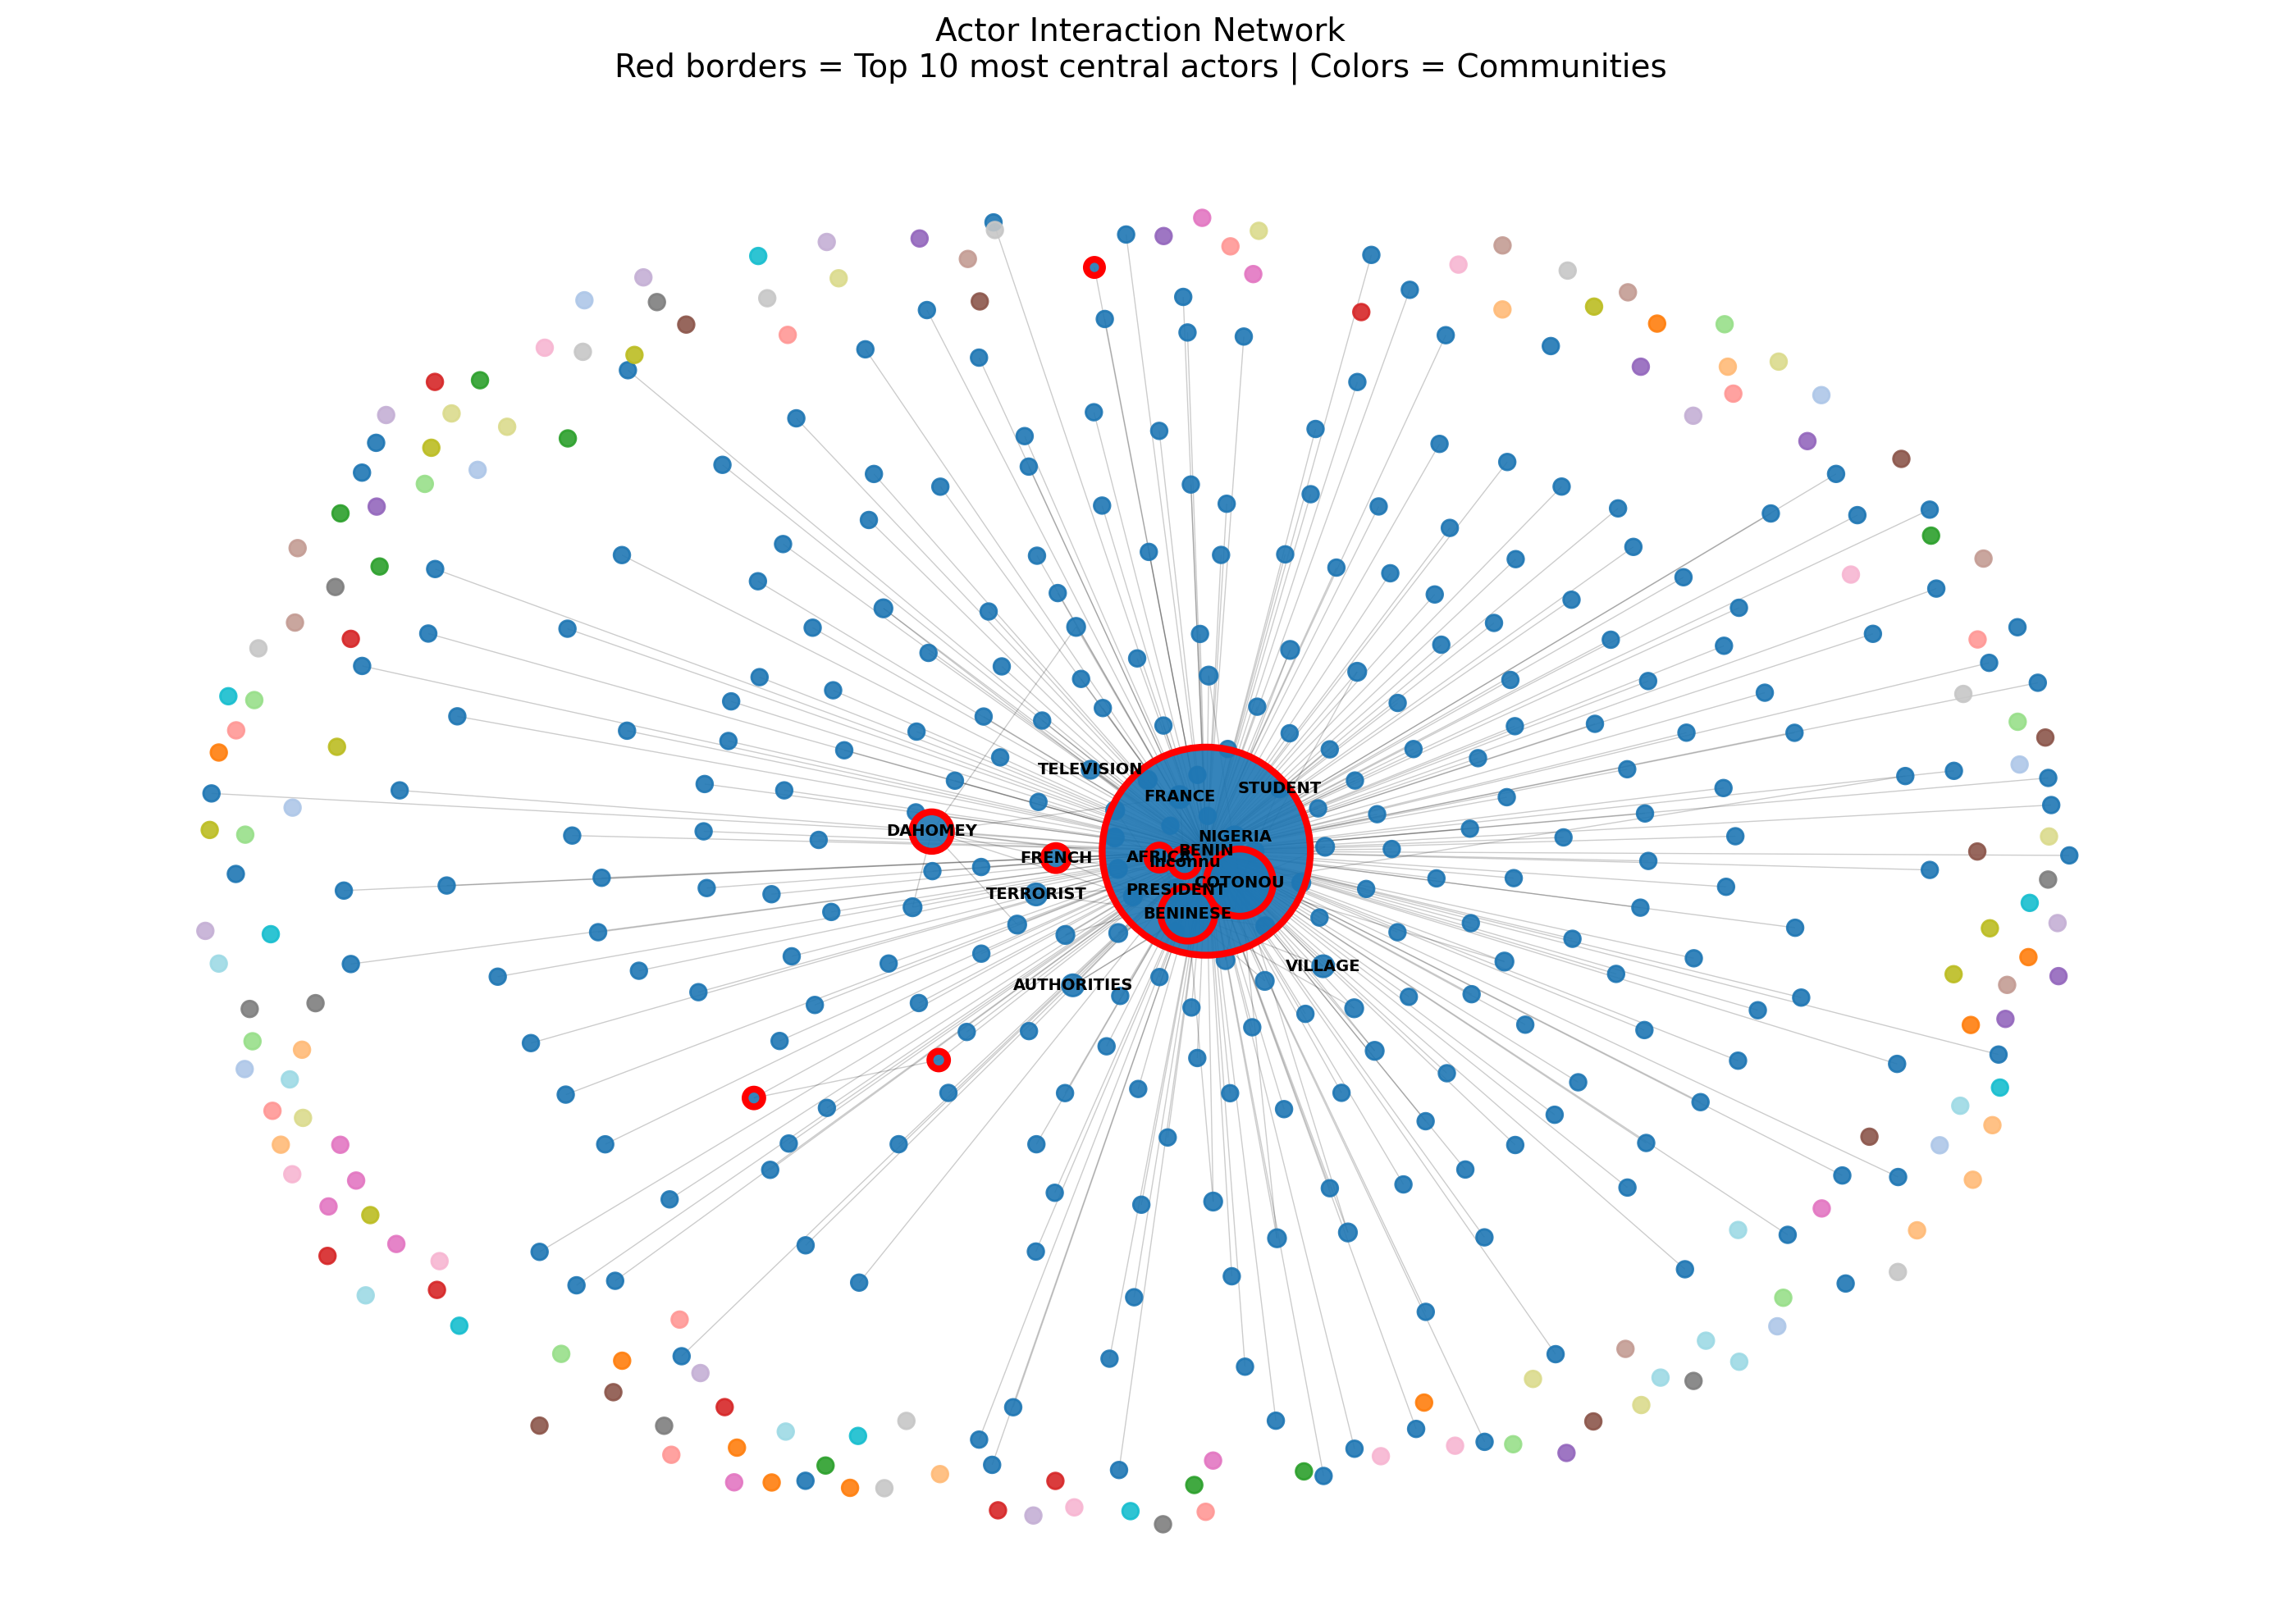

In [4]:
# Improved visualization: communities + centrality
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import community
# layout & centrality
pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)
degrees = dict(G.degree())
betweenness = nx.betweenness_centrality(G)
# detect communities (Louvain)
communities_gen = community.greedy_modularity_communities(G)
community_map = {}
for idx, comm in enumerate(communities_gen):
    for node in comm:
        community_map[node] = idx
# node colors by community, sizes by degree
node_colors_vals = [community_map.get(n, 0) for n in G.nodes()]
node_sizes = [max(50, degrees.get(n, 1) * 30) for n in G.nodes()]
# top 10 central actors
top_central = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
top_central_nodes = {n for n, _ in top_central}
# draw
plt.figure(figsize=(14, 10), dpi=200)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors_vals, cmap='tab20', alpha=0.9)
# highlight top central nodes with red edgecolor
central_nodes = [n for n in G.nodes() if n in top_central_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=central_nodes, node_size=[node_sizes[list(G.nodes()).index(n)] for n in central_nodes], edgecolors='red', linewidths=3, node_color='none')
# labels only for top 15 by degree
top_by_degree = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:15]
labels = {n: n for n, _ in top_by_degree}
nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold')
plt.title('Actor Interaction Network\nRed borders = Top 10 most central actors | Colors = Communities', fontsize=14)
plt.axis('off')
plt.tight_layout()
OUT = project_root / 'reports'
OUT.mkdir(parents=True, exist_ok=True)
out_png = OUT / 'actor_network.png'
plt.savefig(out_png, dpi=300, bbox_inches='tight')
print(f'Saved to {out_png}')
print(f'Communities: {len(communities_gen)} | Top central actors: {[n for n, _ in top_central]}')
plt.show()

Notes:
- Ajuster `min_edge_weight` pour contrôler la densité du graphe.
- Pour de grands graphes, augmenter `min_edge_weight` ou agréger par pays/rôle.
- Intégration Streamlit: utilisez `st.plotly_chart(fig)` dans une page `dashboard/pages/` pour l'afficher dans l'app.